In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
df = pd.read_csv('loan_sanction_test.csv')

In [ ]:
#Display First 5 Rows
df.head(6)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,LP001054,Male,Yes,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban


In [ ]:
#Dataset Information
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [ ]:
#Missing Values
df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [ ]:
#Handle Missing Values
df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
df["Dependents"].fillna(df["Dependents"].mode()[0], inplace=True)
df["Self_Employed"].fillna(df["Self_Employed"].mode()[0], inplace=True)
df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)
df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)

/tmp/ipykernel_560/3597120825.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Gender"].fillna(df["Gender"].mode()[0], inplace=True)
/tmp/ipykernel_560/3597120825.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [ ]:
#Statistical Summary
df.describe()

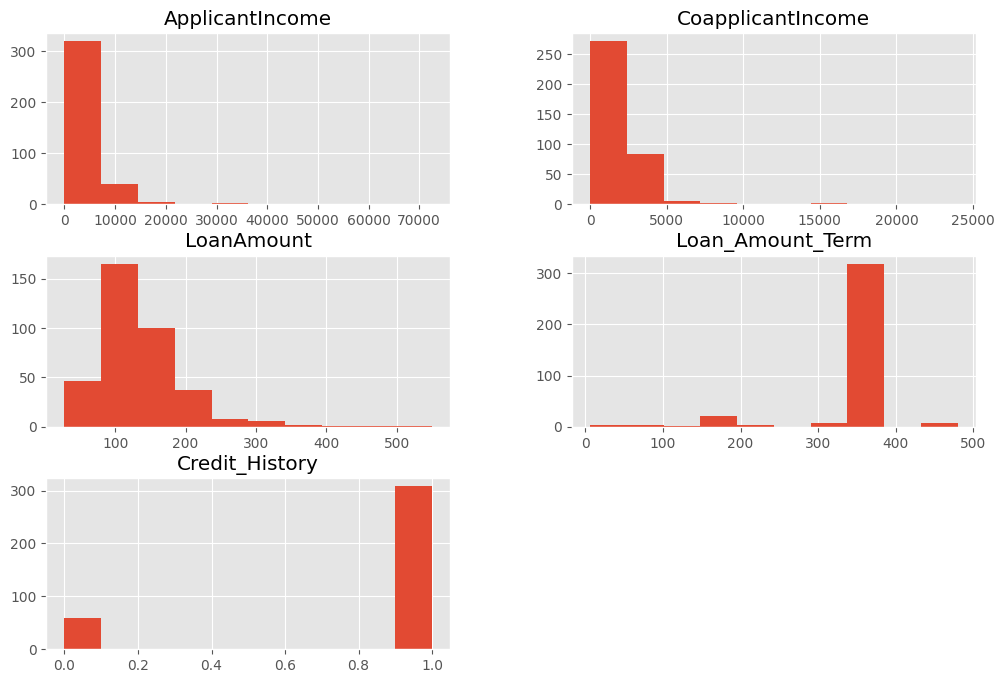

In [ ]:
                                                                      # Univariate Analysis
#Histograms
df.hist(figsize=(12,8))
plt.show()

In [ ]:
#Boxplots
num_cols=["ApplicantIncome","CoapplicantIncome","LoanAmount"]

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [ ]:
#Bar Chrat
sns.countplot(x="Gender",data=df)
plt.show()

sns.countplot(x="Education",data=df)
plt.show()

sns.countplot(x="Property_Area",data=df)
plt.show()

In [ ]:
#pie chart
df["Gender"].value_counts().plot.pie(autopct="%1.1f%%")
plt.ylabel("")
plt.show()

df["Education"].value_counts().plot.pie(autopct="%1.1f%%")
plt.ylabel("")
plt.show()

In [ ]:
                                                                      #Bivariate Analysis
#Scatter Plot
sns.scatterplot(x="ApplicantIncome",
                y="LoanAmount",
                data=df)
plt.show()


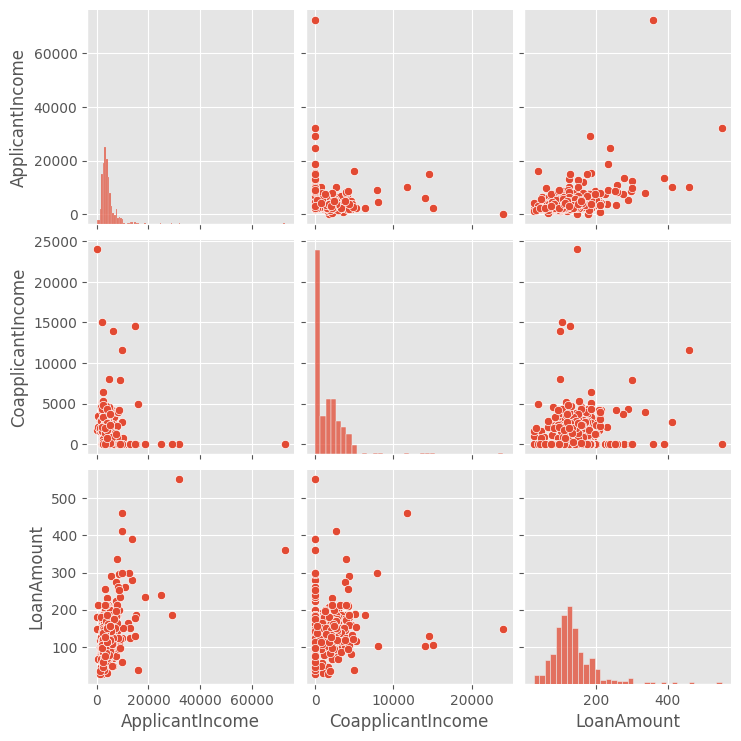

In [ ]:
 #Pair Plot
 sns.pairplot(df[["ApplicantIncome",
                 "CoapplicantIncome",
                 "LoanAmount"]])
plt.show()

In [ ]:
#Box Plot
sns.boxplot(x="Education",
            y="LoanAmount",
            data=df)
plt.show()

sns.boxplot(x="Property_Area",
            y="ApplicantIncome",
            data=df)
plt.show()

In [ ]:
                                                                  #Multivariate Analysis
#Correlation
corr=df.select_dtypes(include=np.number).corr()
corr

In [ ]:
#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")
plt.show()

In [ ]:
#Stacked Bar Chart
pd.crosstab(df["Property_Area"],
            df["Education"]).plot(kind="bar",
                                  stacked=True)

plt.show()

###**Key Insights**
- Dataset contains 367 rows and 12 columns.
- Missing values exist in Gender, Dependents, Self_Employed, LoanAmount, Loan_Amount_Term, and Credit_History.
- Male applicants are more than female applicants.
- Most applicants are Graduates.
- Urban property area has the highest number of applicants.
- Applicant Income and Loan Amount contain outliers.
- Loan Amount is slightly positively related to Applicant Income.
- Credit History has little variation (mostly 1).
- Loan Amount Term is mostly 360 months.
- Correlation among numeric variables is generally weak.